<a href="https://colab.research.google.com/github/rohithmeka/Monte-Carlo-Based-Protein-Folding-Using-the-HP-Lattice-Model/blob/main/2D_HP_Lattice_Protein_Folding_Simulation_(Toy_Model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== FORCE-FOLD RUN ===
Sequence=HHPHHHHHHHHHHHHPHHHHHHHHPHPHHHHHHHHH  Target_E=-2  MaxRestarts=40  StepsPerRun=8000
[RESTART 1] best_e=-21  (target -2)
[SUCCESS] Found fold with energy -21 on restart 1 in 3.1s


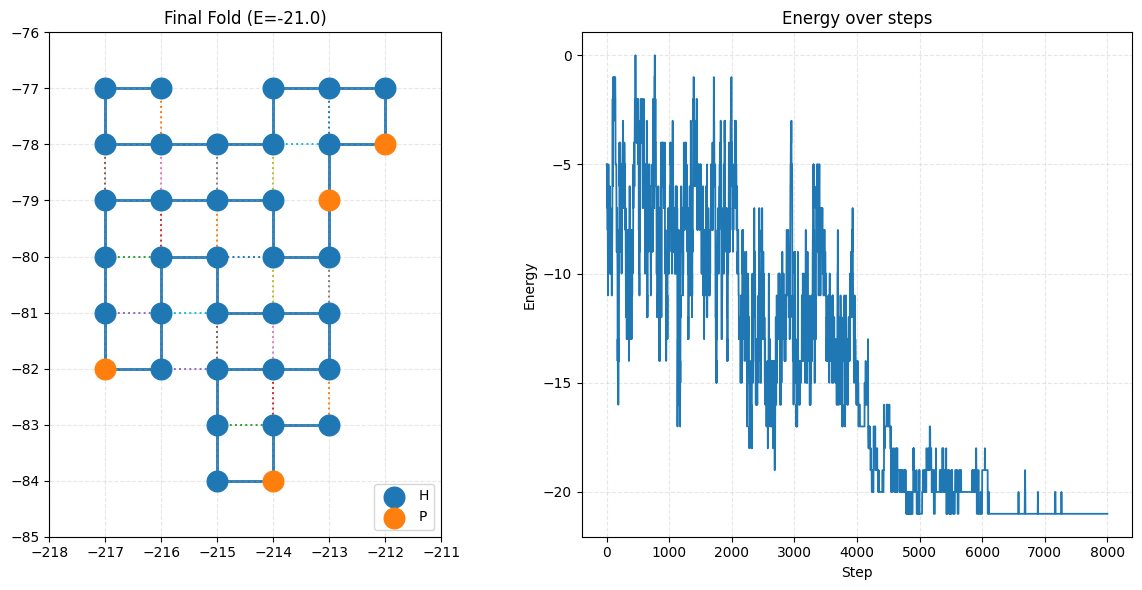

[SAVED] fold -> /content/fold.png
[SAVED] energy -> /content/energy_history.png
=== DONE ===


In [ ]:
import random, math, os, time, traceback
import matplotlib.pyplot as plt
import numpy as np
SEQUENCE = "HHPHHHHHHHHHHHHPHHHHHHHHPHPHHHHHHHHH"
TARGET_ENERGY = -2
MAX_RESTARTS = 40
STEPS_PER_RUN = 8000
TEMPERATURE = 2.0
USE_ANNEALING = True
ANNEAL_EPOCH = 2000
RANDOM_SEED = 999
PROPOSAL_ATTEMPTS_PER_STEP = 12
SAVE_FOLD = "/content/fold.png"
SAVE_ENERGY = "/content/energy_history.png"
VERBOSE = True
# Compactness parameters
COMPACTNESS_WEIGHT = 0.25  # small weight so energy remains primary objective
RG_SCALE = math.sqrt(len(SEQUENCE)) if len(SEQUENCE) > 0 else 1.0

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def calculate_energy(coords, sequence): #For every H residue, checks its four lattice neighbors.
#If a neighbor is also H, not directly bonded and hasn’t been counted before, it subtracts 1 from the energy.
#So energy equals -1 times the number of non-bonded H–H contacts.
    """HP model energy: count non-sequential H-H neighbors (each contact -1)."""
    energy = 0
    N = len(sequence)
    coord_to_index = {coords[i]: i for i in range(N)}
    for i in range(N):
        if sequence[i] != 'H':
            continue
        x, y = coords[i]
        for nb in ((x+1,y),(x-1,y),(x,y+1),(x,y-1)):
            j = coord_to_index.get(nb)
            if j is None: continue
            if sequence[j] != 'H': continue
            if abs(i - j) <= 1: continue  # skip bonded neighbors
            if i < j:
                energy -= 1
    return energy

def is_self_avoiding(coords):   #Checks that no two residues share the same (x,y).
    return len(coords) == len(set(coords))

def is_connected(coords): #Ensures each residue is adjacent to the next; i.e., the chain has no breaks.
    for i in range(len(coords)-1):
        x1,y1 = coords[i]; x2,y2 = coords[i+1]
        if abs(x1-x2) + abs(y1-y2) != 1:
            return False
    return True

def is_valid_configuration(coords): #both of the above
    return is_self_avoiding(coords) and is_connected(coords)

def random_self_avoiding_walk(N, max_attempts=5000): #Repeatedly tries to grow a chain one step at a time,
                                      #choosing a random free neighbor at each step. If it gets stuck, it restarts and tries again.
    """Return a list of N coordinates forming a SAW, or None if failed."""
    for attempt in range(max_attempts):
        coords = [(0,0)]
        directions = [(1,0),(-1,0),(0,1),(0,-1)]
        success = True
        for i in range(1, N):
            neighbors = [(coords[-1][0]+dx, coords[-1][1]+dy) for dx,dy in directions]
            free = [p for p in neighbors if p not in coords]
            if not free:
                success = False
                break
            coords.append(random.choice(free))
        if success and is_valid_configuration(coords):
            return coords
    return None

def spiral_initializer(N): #Builds a deterministic square/rectangular spiral starting at (0,0) to produce a compact starting conformation.
                           #If the spiral somehow isn’t a valid chain, it returns a straight line.
    coords = [(0,0)]
    step = 1
    dir_idx = 0
    dirs = [(1,0),(0,1),(-1,0),(0,-1)]
    while len(coords) < N:
        for _ in range(2):
            dx,dy = dirs[dir_idx % 4]
            for _ in range(step):
                if len(coords) >= N: break
                x,y = coords[-1]
                coords.append((x+dx,y+dy))
            dir_idx += 1
        step += 1
    if is_valid_configuration(coords[:N]): #counts non-sequential H–H neighboring contacts. Each valid contact contributes -1 to energy.
        return coords[:N]
    return [(i,0) for i in range(N)]

def radius_of_gyration(coords): #Computes how spread-out the chain is around its center — smaller = more compact.
                                #Used as a tie-breaker favoring compact folds.
    xs = [p[0] for p in coords]; ys = [p[1] for p in coords]
    cx = sum(xs) / len(xs); cy = sum(ys) / len(ys)
    return math.sqrt(sum((x-cx)**2 + (y-cy)**2 for x,y in coords) / len(coords))

def propose_end_move(coords): #Tries to move one of the two endpoints to a neighboring free lattice site
                              #If that move keeps the chain valid, returns it.
    N = len(coords); end = random.choice([0, N-1]); neigh = 1 if end==0 else N-2
    px,py = coords[neigh]
    cand = [(px+1,py),(px-1,py),(px,py+1),(px,py-1)]; random.shuffle(cand)
    for c in cand:
        if c in coords: continue
        new = list(coords); new[end] = c
        if is_valid_configuration(new): return new
    return None

def propose_corner_flip(coords): #Picks an interior residue that sits at a corner
                                #tries to flip it into the mirrored corner position; returns the flipped chain if valid.
    N = len(coords)
    if N < 3: return None
    i = random.randint(1, N-2)
    a,b,c = coords[i-1], coords[i], coords[i+1]
    if a[0] == c[0] or a[1] == c[1]: return None
    newpos = (a[0] + c[0] - b[0], a[1] + c[1] - b[1])
    if newpos in coords: return None
    new = list(coords); new[i] = newpos
    if is_valid_configuration(new): return new
    return None

def propose_crankshaft(coords): #Picks four consecutive residues (a,b,c,d) where endpoints a and d are adjacent
                         #and tries to rotate the middle two into a new pair of adjacent positions if those target positions are free.
    N = len(coords)
    if N < 4: return None
    i = random.randint(0, N-4)
    a,b,c,d = coords[i], coords[i+1], coords[i+2], coords[i+3]
    if abs(a[0]-d[0]) + abs(a[1]-d[1]) != 1: return None
    neigh_a = [(a[0]+1,a[1]),(a[0]-1,a[1]),(a[0],a[1]+1),(a[0],a[1]-1)]
    neigh_d = [(d[0]+1,d[1]),(d[0]-1,d[1]),(d[0],d[1]+1),(d[0],d[1]-1)]
    for na in neigh_a:
        for nd in neigh_d:
            if na in coords or nd in coords: continue
            if abs(na[0]-nd[0]) + abs(na[1]-nd[1]) != 1: continue
            new = list(coords); new[i+1] = na; new[i+2] = nd
            if is_valid_configuration(new): return new
    return None

def rotate_point_around(p, pivot, clockwise=True): #Rotates p by 90° around pivot.
              #If clockwise it applies the (x,y)->(y,-x) style transform on the vector relative to pivot, otherwise the opposite.
    px,py = pivot; x,y = p; tx,ty = x-px, y-py
    if clockwise: rx,ry = ty, -tx
    else: rx,ry = -ty, tx
    return (px+rx, py+ry)

def propose_pivot_move(coords): #Chooses an internal pivot residue and rotates either the entire tail
#or the entire head (before pivot) around that pivot by ±90°. This can produce large changes; it returns the result only
#if it remains a valid chain.
    N = len(coords)
    if N < 3: return None
    pivot = random.randint(1, N-2)  # pivot not endpoints
    rotate_tail = random.choice([True, False])
    clockwise = random.choice([True, False])
    if rotate_tail:
        pivot_pos = coords[pivot]; new = coords[:pivot+1]
        for j in range(pivot+1, N):
            newp = rotate_point_around(coords[j], pivot_pos, clockwise)
            new.append(newp)
    else:
        pivot_pos = coords[pivot]; new = []
        for j in range(0, pivot):
            newp = rotate_point_around(coords[j], pivot_pos, clockwise)
            new.append(newp)
        new += coords[pivot:]
    if is_valid_configuration(new): return new
    return None

def propose_local_shift(coords): #Picks an interior residue
        #and tries to move it one lattice step in one of four directions; accepts only if the chain stays valid. A small local tweak.
    N = len(coords)
    if N <= 2: return None
    idx = random.randint(1, N-2)
    x,y = coords[idx]; dirs = [(1,0),(-1,0),(0,1),(0,-1)]; random.shuffle(dirs)
    for dx,dy in dirs:
        newp = (x+dx,y+dy)
        if newp in coords: continue
        new = list(coords); new[idx] = newp
        if is_valid_configuration(new): return new
    return None

def propose_pull_toward_centroid(coords): #Picks an interior residue
            #and tries to nudge it one step toward the chain’s centroid (x and/or y). This biases the chain to become more compact.
    N = len(coords)
    if N <= 2: return None
    idx = random.randint(1, N-2)
    cx = sum(x for x,y in coords) / N
    cy = sum(y for x,y in coords) / N
    x,y = coords[idx]
    dx = 0 if abs(cx - x) < 0.5 else (1 if cx > x else -1)
    dy = 0 if abs(cy - y) < 0.5 else (1 if cy > y else -1)
    candidates = []
    if dx != 0: candidates.append((x+dx, y))
    if dy != 0: candidates.append((x, y+dy))
    if dx != 0 and dy != 0: candidates.append((x+dx, y+dy))
    random.shuffle(candidates)
    for np_ in candidates:
        if np_ in coords: continue
        new = list(coords); new[idx] = np_
        if is_valid_configuration(new): return new
    return None

def propose_move(coords):#Randomly picks one of the move types above according to preset probabilities Central dispatcher of move proposals.
    r = random.random()
    if r < 0.05:
        return propose_end_move(coords)
    if r < 0.60:
        return propose_pivot_move(coords)
    if r < 0.85:
        return propose_crankshaft(coords)
    if r < 0.92:
        return propose_pull_toward_centroid(coords)
    if r < 0.97:
        return propose_corner_flip(coords)
    return propose_local_shift(coords)

#Runs a Monte-Carlo (Metropolis) search starting from coords_init.
#At each step it tries up to attempt_limit proposals (via propose_move),
#scores them using energy + small compactness term, and accepts if better or with some probability if worse (based on temp).
#Optionally lowers temp in epochs (annealing). It keeps the best conformation seen and returns it plus the energy history.
def monte_carlo_folding_from(coords_init, sequence, max_iter=2000, temp=1.0, attempt_limit=12, use_annealing=False):
    curr = list(coords_init) #keeps the best cordinates been so far
    if not is_valid_configuration(curr):
        raise RuntimeError("initial invalid")
    curr_e = calculate_energy(curr, sequence)
    curr_rg = radius_of_gyration(curr)
    best, best_e, best_rg = list(curr), curr_e, curr_rg
    history = [curr_e]
    for step in range(max_iter):
        # annealing schedule
        T = temp
        if use_annealing and ANNEAL_EPOCH > 0:  #Optionally reduces temperature according to ANNEAL_EPOCH
            T = temp * (0.5 ** (step // ANNEAL_EPOCH))
            if T < 1e-6: T = 1e-6

        for attempt in range(attempt_limit): #Tries up to attempt_limit proposals: compute energy & composite score for proposed conformation
            prop = propose_move(curr)
            if prop is None: continue
            e2 = calculate_energy(prop, sequence)
            prop_rg = radius_of_gyration(prop)

            curr_score = curr_e + COMPACTNESS_WEIGHT * (curr_rg / RG_SCALE) #Accepts moves that improve score; otherwise accepts with Boltzmann probability exp(-Δscore / T)
            prop_score = e2 + COMPACTNESS_WEIGHT * (prop_rg / RG_SCALE)
            dScore = prop_score - curr_score

            if dScore < 0:
                accept = True
            else:
                try:
                    p_acc = math.exp(-dScore / max(1e-12, T))
                except OverflowError:
                    p_acc = 0.0
                accept = (random.random() < p_acc)

            if accept:
                curr, curr_e, curr_rg = prop, e2, prop_rg
                if curr_e < best_e or (curr_e == best_e and curr_rg < best_rg):
                    best, best_e, best_rg = list(curr), curr_e, curr_rg
                break

        history.append(curr_e)
    return best, best_e, history #Returns the best conformation found in that run, its energy, and the energy history.

def plot_and_display(coords, seq, energy, history, save_fold=SAVE_FOLD, save_energy=SAVE_ENERGY, show=True):
#Draws the final chain in 2D:
#Line connecting residues, scatter points for residues.
#Large markers for H and P.
#Dotted lines for H–H non-bonded contacts.
#Plots energy vs step and saves both images to SAVE_FOLD and SAVE_ENERGY.
#Prints status messages when saving (controlled by VERBOSE).
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(121)
    xs, ys = zip(*coords)
    ax1.plot(xs, ys, '-', linewidth=2, zorder=1)
    ax1.scatter(xs, ys, s=60, facecolor='white', edgecolor='black', zorder=3)
    # colors
    h_x = [x for x,r in zip(xs, seq) if r=='H']; h_y = [y for y,r in zip(ys, seq) if r=='H']
    p_x = [x for x,r in zip(xs, seq) if r=='P']; p_y = [y for y,r in zip(ys, seq) if r=='P']
    ax1.scatter(h_x,h_y, s=220, label='H', zorder=4)
    ax1.scatter(p_x,p_y, s=220, label='P', zorder=4)
    coord_index = {coords[i]: i for i in range(len(coords))}
    for i in range(len(seq)):
        if seq[i] != 'H': continue
        x,y = coords[i]
        for nb in ((x+1,y),(x-1,y),(x,y+1),(x,y-1)):
            j = coord_index.get(nb)
            if j is None: continue
            if j <= i: continue
            if seq[j] != 'H': continue
            if abs(i-j) <= 1: continue
            xj,yj = coords[j]; ax1.plot([x,xj],[y,yj],':', linewidth=1.4, zorder=2)
    ax1.set_title(f'Final Fold (E={energy:.1f})'); ax1.set_aspect('equal', adjustable='box'); ax1.grid(True, linestyle='--', alpha=0.3)
    pad = 1; ax1.set_xlim(min(xs)-pad, max(xs)+pad); ax1.set_ylim(min(ys)-pad, max(ys)+pad)
    ax1.legend(loc='lower right')

    ax2 = fig.add_subplot(122); ax2.plot(history, linewidth=1.3); ax2.set_title('Energy over steps'); ax2.set_xlabel('Step'); ax2.set_ylabel('Energy'); ax2.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    if show: plt.show()

    try:
        fig.savefig(save_fold, dpi=200)
        if VERBOSE: print(f"[SAVED] fold -> {save_fold}")
    except Exception as e:
        print("[WARN] save fold failed:", e)
    try:
        f2 = plt.figure(figsize=(6,4)); a2 = f2.add_subplot(111); a2.plot(history); a2.set_title('Energy over steps'); a2.grid(True, linestyle='--', alpha=0.3)
        f2.savefig(save_energy, dpi=160); plt.close(f2)
        if VERBOSE: print(f"[SAVED] energy -> {save_energy}")
    except Exception as e:
        print("[WARN] save energy failed:", e)
#Repeats many independent Monte-Carlo runs (restarts) to try different parts of search space.
#Every 5th restart it uses the spiral initializer, otherwise a random SAW.
#Tracks the best solution across restarts; stops early if a run reaches target_energy. Finally shows or saves the best fold.
def force_fold(sequence, target_energy, max_restarts, steps_per_run, temp, use_annealing=False):
    N = len(sequence)
    total_H = sequence.count('H')
    if total_H < 2:
        print("[INFO] Not enough H residues to get contacts. Exiting.")
        return None
#Tracks the best conformation over all restarts.
#If a run finds an energy ≤ target_energy, it stops and displays that fold.
    best_overall = None
    best_e_overall = float('inf')
    best_history_overall = None
    start_time = time.time()
#If nothing reaches the target, it shows the best overall found.
    for restart in range(1, max_restarts+1):
        # use spiral sometimes to bias toward compact start
        if restart % 5 == 0:
            init = spiral_initializer(N)
            if VERBOSE: print(f"[RESTART {restart}] using spiral initializer")
        else:
            init = random_self_avoiding_walk(N)
            if init is None:
                if VERBOSE: print(f"[WARN] SAW gen failed on restart {restart}; fallback to straight chain")
                init = [(i,0) for i in range(N)]

        best, best_e, history = monte_carlo_folding_from(init, sequence, max_iter=steps_per_run, temp=temp, attempt_limit=PROPOSAL_ATTEMPTS_PER_STEP, use_annealing=use_annealing)

        if VERBOSE:
            print(f"[RESTART {restart}] best_e={best_e}  (target {target_energy})")

        if best_e < best_e_overall:
            best_overall, best_e_overall, best_history_overall = best, best_e, history

        if best_e <= target_energy:
            elapsed = time.time() - start_time
            if VERBOSE: print(f"[SUCCESS] Found fold with energy {best_e} on restart {restart} in {elapsed:.1f}s")
            plot_and_display(best, sequence, best_e, history)
            return best, best_e, history

    if VERBOSE:
        print("[FAILURE] Did not reach target energy after max restarts.")
    if best_overall is not None:
        if VERBOSE:
            print(f"[BEST OVERALL] energy={best_e_overall} — showing best found")
        plot_and_display(best_overall, sequence, best_e_overall, best_history_overall)
    else:
        print("[ERROR] No valid conformation found at all.")
    return best_overall, best_e_overall, best_history_overall

#prints run settings, calls force_fold, and wraps it in try/except to print a traceback if something crashes.
if __name__ == "__main__":
    try:
        print("=== FORCE-FOLD RUN ===")
        print(f"Sequence={SEQUENCE}  Target_E={TARGET_ENERGY}  MaxRestarts={MAX_RESTARTS}  StepsPerRun={STEPS_PER_RUN}")
        result = force_fold(SEQUENCE, TARGET_ENERGY, MAX_RESTARTS, STEPS_PER_RUN, TEMPERATURE, use_annealing=USE_ANNEALING)
        print("=== DONE ===")
    except Exception:
        print("[ERROR] Exception during force-fold run:")
        traceback.print_exc()